# Treball 3: PageRank - Com ordena Google les pàgines web

Històricament, el Vallès ha tingut múltiples capitals, ara mateix sent Terrassa, Sabadell i Granollers, i sempre hi ha hagut el debat de quina és la ciutat més important del Vallès. Com es podria mesurar quina és? PageRank serveix precisament per això, dissenyat per veure quines són les pàgines web més importants. Si canviem pàgina web per ciutat, tindrem la resposta i finalment podrem tancar el debat històric.

**Grup H** — Eduardo Pérez Motato (1709992), Félix Sáiz von Fraunberg (1620854), Benet Carbonell Fusté (1709685)

Carreguem les llibreries necessàries: `networkx` per visualització dels grafs, `numpy` per càlcul matricial, `matplotlib` per visualització, `ipywidgets` per interactiu.

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets
import copy

Llegim `nameToId.txt` per obtenir els identificadors Viquipèdia dels 61 municipis del Vallès. Construïm els diccionaris de lookup `idToName`, `id_to_pos` i `pos_to_id` per indexar la matriu.

In [2]:
nameToId : dict[str:int] = {}
idToName : dict[int:str] = {}
with open("allPageRank/nameToId.txt") as f:
    for line in f.readlines():
        nom, w_id = line.split(" :: ")
        nameToId[nom] = int(w_id)
        idToName[int(w_id)] = nom

id_to_pos = {id: i for i, id in enumerate(idToName)}
pos_to_id = {i: id for i, id in enumerate(idToName)}

`carregar_conexions_valles()` llegeix `entriesConnections.txt` i filtra només les connexions entre els 61 municipis del Vallès. `conexions_a_matriu()` construeix la matriu de transició $P$ on cada columna $i$ distribueix probabilitat $1/\text{grau}(i)$ entre els successors de $i$.

In [3]:
def carregar_conexions_valles() -> dict[int:list[int]]:
    valles_connections:dict[int:list[int]] = {}

    with open("allPageRank/entriesConnections.txt") as f:
        for line in f.read().split("\n"):
            if line == "": continue
            source, connections = line.split(" :: ")
            if not len(connections) == 0:
                connections = connections.split(" ")
            if int(source) in idToName.keys():
                valles_connections[int(source)] = [int(conn) for conn in connections if not conn == ""]

    for (pob, conn) in valles_connections.items():
        valles_connections[pob] = list(filter(lambda x: x in idToName.keys(), conn))

    return valles_connections

def conexions_a_matriu(matriu_dajacencia: dict[int:list[int]]) -> np.matrix:
    valles_matrix = np.zeros((len(matriu_dajacencia), len(matriu_dajacencia)))

    for (pob, conn) in matriu_dajacencia.items():
        if len(conn) == 0: continue
        for dest in conn:
            valles_matrix[id_to_pos[dest]][id_to_pos[pob]] = 1/len(conn)

    return valles_matrix


def arreglar_inconexos(matriu_dajacencia:np.matrix) -> np.matrix:
    for i, col in enumerate(matriu_dajacencia.T):
        if col.sum() == 0:
            for j in range(len(col)):
                matriu_dajacencia[j][i] = 1/len(id_to_pos)

    return matriu_dajacencia

`arreglar_inconexos()` aplica el protocol estàndard per dangling nodes: columnes nul·les es reemplacen per distribució uniforme $1/N$. `mostrar_graf()` renderitza el graf dirigit amb `spring_layout`; la mida i el color dels nodes codifiquen el PageRank via colormap `viridis`.

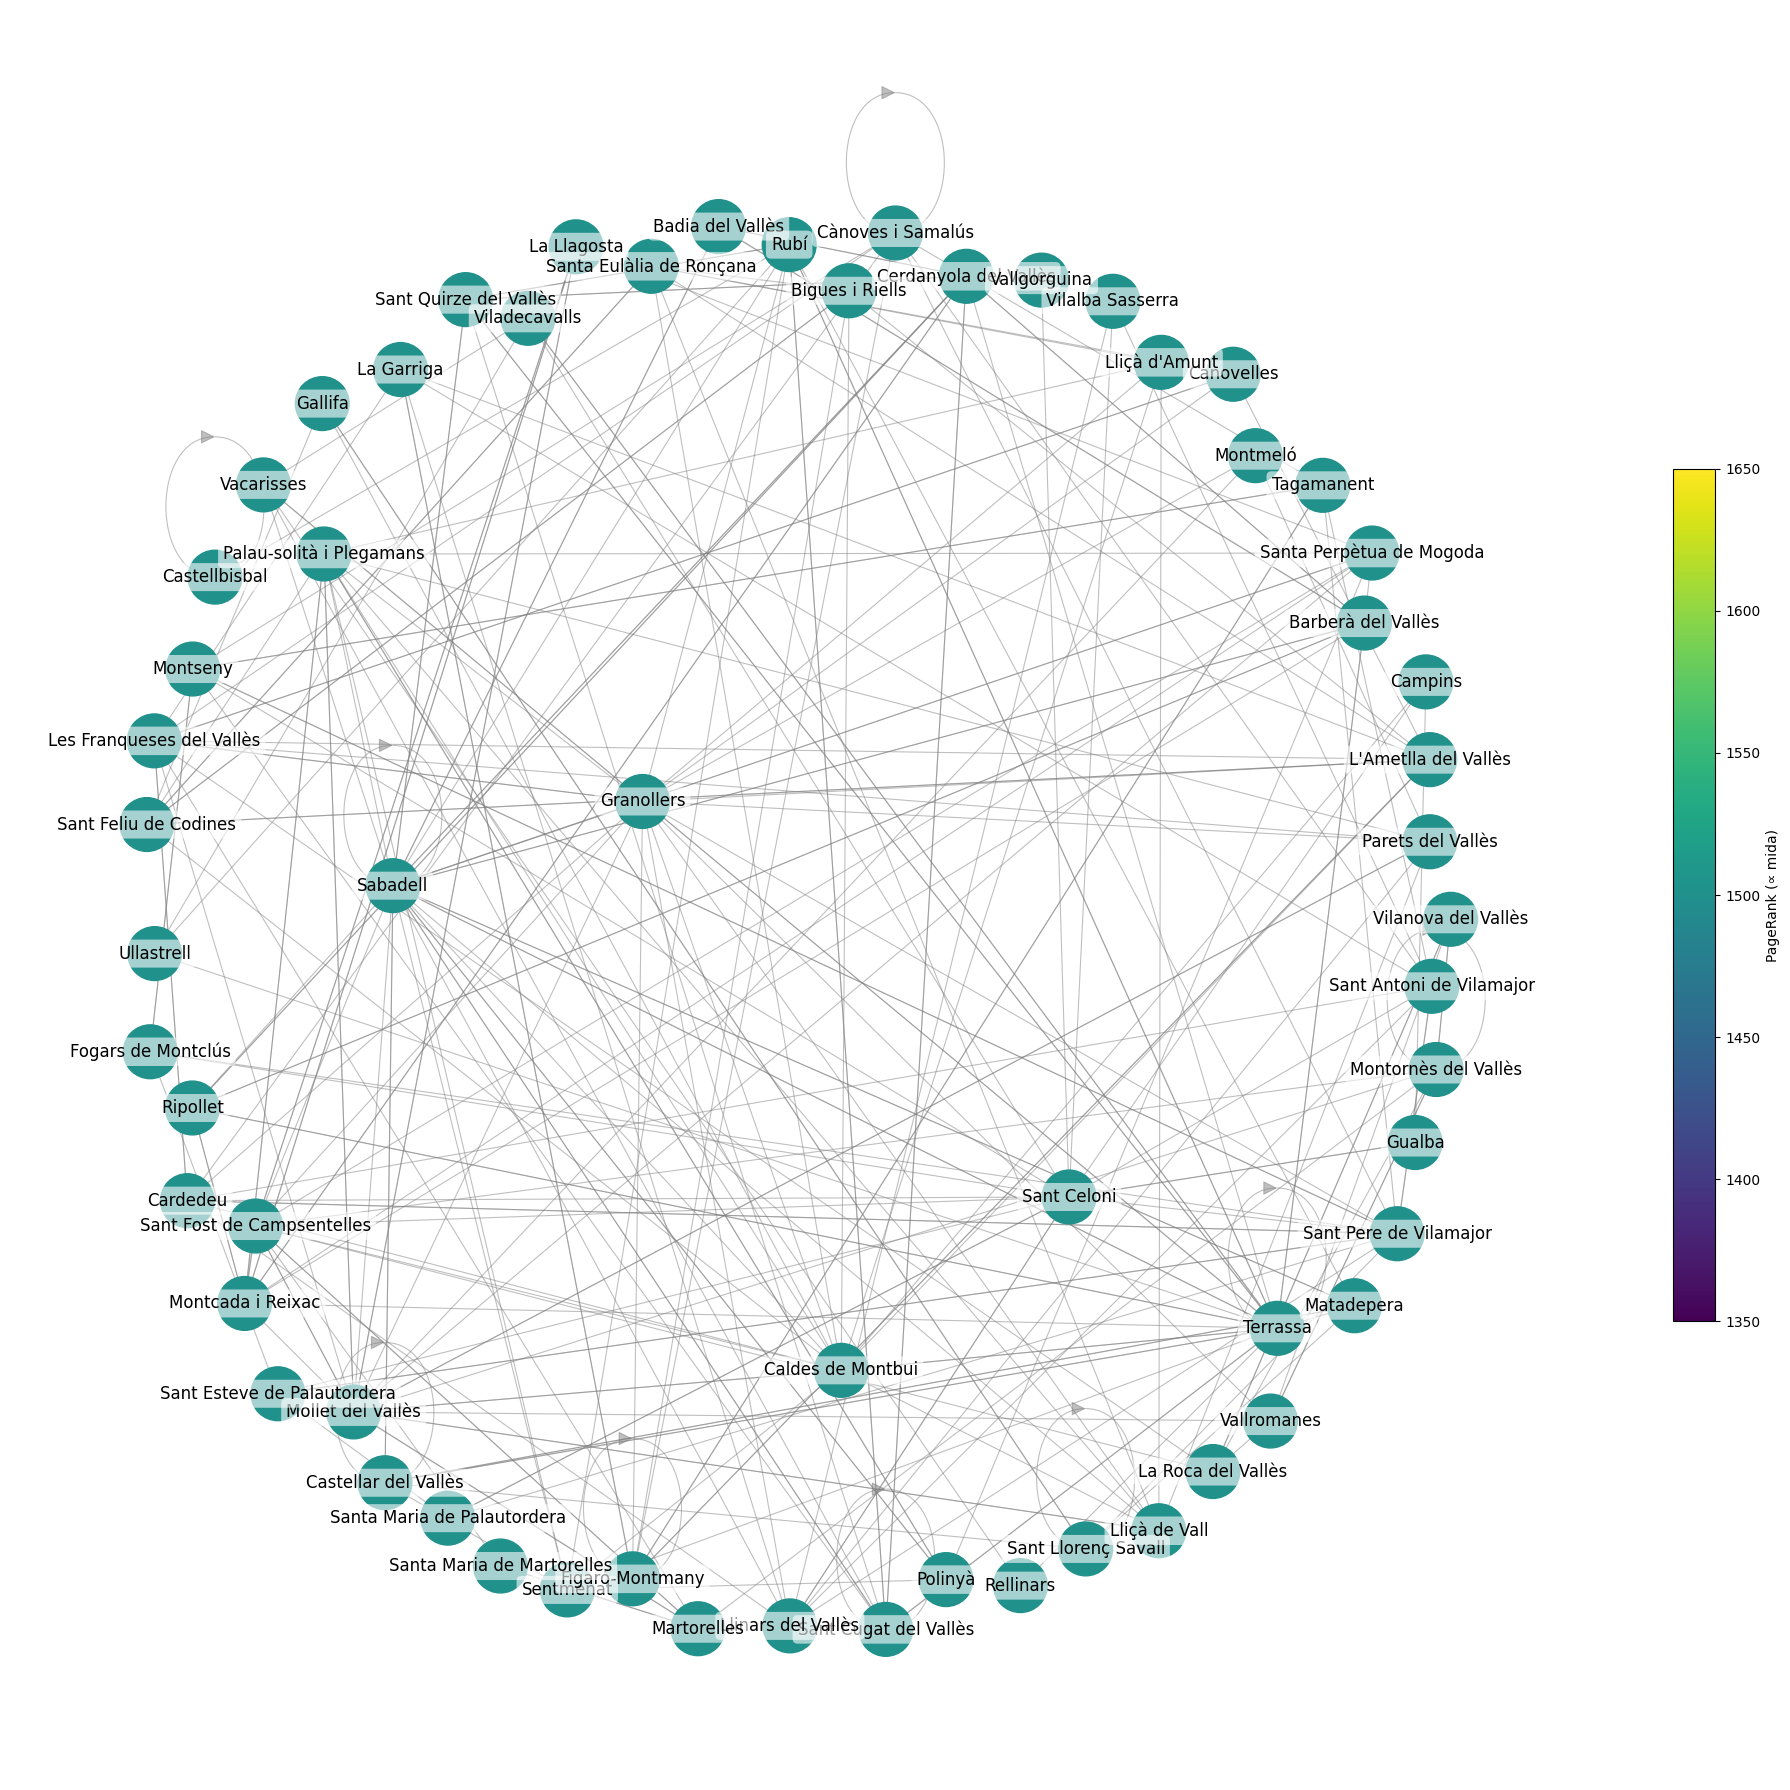

In [4]:
def mostrar_graf(matriu_dajacencia: np.ndarray, mides_nodes: list[int] | None = None) -> None:
    N = matriu_dajacencia.shape[0]
    if mides_nodes is None:
        mides_nodes = [1500] * N

    full_connect = {i for i in range(N)
                    if np.count_nonzero(matriu_dajacencia[:, i]) == N}

    G = nx.from_numpy_array(matriu_dajacencia, create_using=nx.DiGraph)
    normal_edges = [(u, v) for u, v in G.edges()
                    if u not in full_connect and v not in full_connect]
    dotted_edges = [(u, v) for u, v in G.edges()
                    if u in full_connect or v in full_connect]

    pos = nx.spring_layout(G, k=3.0, seed=42, iterations=100)
    labels = {i: idToName[id] for id, i in id_to_pos.items()}

    fig, ax = plt.subplots(figsize=(18, 18))

    nodes = nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_color=mides_nodes, cmap="viridis",   # color = PageRank
        node_size=mides_nodes,
    )
    nx.draw_networkx_labels(
        G, pos, labels=labels, ax=ax, font_size=12,
        bbox=dict(boxstyle="round", fc="white", ec="none", alpha=0.6),
    )
    nx.draw_networkx_edges(G, pos, edgelist=normal_edges, ax=ax,
                           alpha=0.5, width=0.8, edge_color="gray",
                           arrows=True, arrowstyle='-|>', arrowsize=22)
    nx.draw_networkx_edges(G, pos, edgelist=dotted_edges, ax=ax,
                           style='dotted', alpha=0.12, width=0.5, edge_color="red",
                           arrows=True, arrowstyle='-|>', arrowsize=14)

    fig.colorbar(nodes, ax=ax, fraction=0.025, label="PageRank (∝ mida)")
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    plt.close(fig) 
valles_connections = carregar_conexions_valles()
valles_matrix_inconex = conexions_a_matriu(valles_connections)

mostrar_graf(valles_matrix_inconex)

Carreguem les connexions, construïm la matriu sense tractar dangling nodes i visualitzem el graf brut per inspecció prèvia.

In [5]:
def damping(matriu_dajacencia:np.matrix, alpha) -> np.matrix:
    N = matriu_dajacencia.shape[0]

    damping_matrix = np.ones_like(matriu_dajacencia)/N

    M = alpha*matriu_dajacencia + (1-alpha)*damping_matrix

    return M

`damping()` construeix la matriu esmorteïda $M = dP + (1-d)\frac{1}{N}\mathbf{1}\mathbf{1}^T$. `autovector_i_autovalor_dominants()` calcula el vector propi de valor propi dominant de $M$ (que és 1 per construcció). `format_resultat()` mapeja posicions a identificadors i mostra el top-$k$.

In [6]:
def autovector_i_autovalor_dominants(matriu_dajacencia:np.matrix):
    vaps, veps = np.linalg.eig(matriu_dajacencia)

    dom_vap = max(vaps)
    assert np.real(dom_vap) > 0 and not np.iscomplex(dom_vap)
    for vap in vaps: assert dom_vap >= np.abs(vap)
    assert np.count_nonzero(vaps == dom_vap) == 1

    idx = np.where(vaps == dom_vap)
    dom_vap = np.real(vaps[idx])
    dom_vep = veps[:, idx]
    return dom_vap, dom_vep

Apliquem PageRank per autovalors sobre el subgraf del Vallès per $d \in \{0.5, 0.7, 0.85, 0.99\}$. Primer arreglem dangling nodes, després calculem.

In [7]:
def format_resultat(resultat, alpha, truncar:int|None=5):
    if truncar == None: truncar = len(resultat)
    resultat = {pos_to_id[i]: resultat[i] for i in range(len(resultat))}
    print(f"Resultats amb dampening factor {alpha}")
    for id, res in sorted(resultat.items(), key=lambda i: abs(i[1]), reverse=True)[:truncar]:
        print(f"\t{idToName[id]}: {np.real(res)[0][0]}")


def pagerank_nomes_valles(alpha, valles_connections, valles_matrix, truncar:int|None=5):
    valles_matrix = damping(valles_matrix, alpha)

    vap, vep = autovector_i_autovalor_dominants(valles_matrix)

    resultat = vep/vep.sum()

    format_resultat(resultat, alpha, truncar=truncar)

    return resultat



Canòves i Samalús presenta un autobucle que la converteix en atractor de probabilitat per $d$ alts. Per demostrar que és artefacte del subgraf aïllat, modifiquem les seves sortides per apuntar a tots els nodes (simulant integració al graf global de 700K nodes).

In [8]:
valles_connections = carregar_conexions_valles()
valles_matrix_inconex = conexions_a_matriu(valles_connections)
valles_matrix = arreglar_inconexos(valles_matrix_inconex)

pagerank_nomes_valles(0.5, valles_connections, valles_matrix)
pagerank_nomes_valles(0.7, valles_connections, valles_matrix)
pagerank_nomes_valles(0.85, valles_connections, valles_matrix)
pagerank_nomes_valles(0.99, valles_connections, valles_matrix)

pass

Resultats amb dampening factor 0.5
	Sabadell: 0.041495791845342335
	Caldes de Montbui: 0.03921002716323351
	Cànoves i Samalús: 0.038248190608339484
	Granollers: 0.037842014078082124
	Les Franqueses del Vallès: 0.02904067598110247
Resultats amb dampening factor 0.7
	Cànoves i Samalús: 0.06642385706193198
	Sabadell: 0.04988376237877563
	Granollers: 0.044367143213232395
	Caldes de Montbui: 0.042535032740699766
	Les Franqueses del Vallès: 0.03811484186691136
Resultats amb dampening factor 0.85
	Cànoves i Samalús: 0.12467793089820593
	Sabadell: 0.051595067734687826
	Granollers: 0.045264893297594706
	Vilanova del Vallès: 0.045154894800037156
	Les Franqueses del Vallès: 0.042992659302271544
Resultats amb dampening factor 0.99
	Cànoves i Samalús: 0.5521119843155703
	Vilanova del Vallès: 0.07338332917325366
	Montornès del Vallès: 0.0561990915243726
	La Roca del Vallès: 0.05615627059259061
	Castellbisbal: 0.04289569922054625


Amb aixó veiem una dada curiosa, hi es que Cànoves i Samalús es la ciutat més important... Fet que, qualsevol persona et diria que, no sembla certa.

Mirant una mica, veiem que aquest node te una peculiaritat: Només es referencia a si mateix, convertint-lo en un atractor. El dampling pot lluitar contra ell i per aixó no veiem que el seu valor sigui 1. Fem un petit canvi per fer que aquest node referenci a tothom, no només a ell.

In [9]:
valles_connections_cis = copy.deepcopy(valles_connections)
canoves_id = nameToId["Cànoves i Samalús"]
valles_connections_cis[canoves_id] = [i for i in idToName.keys()]
valles_matrix_inconex_cis = conexions_a_matriu(valles_connections_cis)
valles_matrix_cis = arreglar_inconexos(valles_matrix_inconex_cis)

pagerank_nomes_valles(0.5, valles_connections_cis, valles_matrix_cis)
pagerank_nomes_valles(0.7, valles_connections_cis, valles_matrix_cis)
pagerank_nomes_valles(0.85, valles_connections_cis, valles_matrix_cis)
pagerank_nomes_valles(0.99, valles_connections_cis, valles_matrix_cis)

pass

Resultats amb dampening factor 0.5
	Sabadell: 0.04230483351327723
	Caldes de Montbui: 0.03997450337552386
	Granollers: 0.03857981819812047
	Les Franqueses del Vallès: 0.029606880791008865
	Terrassa: 0.026985945023643678
Resultats amb dampening factor 0.7
	Sabadell: 0.05231629756898788
	Granollers: 0.04653066561027792
	Caldes de Montbui: 0.0446092139777311
	Les Franqueses del Vallès: 0.03997347661476037
	Vilanova del Vallès: 0.031913189862338986
Resultats amb dampening factor 0.85
	Sabadell: 0.05771107001407264
	Granollers: 0.0506305261524203
	Vilanova del Vallès: 0.0505074885972292
	Les Franqueses del Vallès: 0.048088944932549255
	Caldes de Montbui: 0.044318415949255105
Resultats amb dampening factor 0.99
	Vilanova del Vallès: 0.16184792811435236
	Montornès del Vallès: 0.12394785883390617
	La Roca del Vallès: 0.12385341668789109
	Castellbisbal: 0.09460704661505755
	Les Franqueses del Vallès: 0.0401070850558646


`pagerank_dibuix()` calcula el PageRank per un $d$ donat, escala els valors per determinar mida i color dels nodes, i crida `mostrar_graf()`.

Tenim amb aixó, una cel·la interactiva. Podem moure el factor d'amortïment i si acceptem Cànoves i Samalús com a node atractor.

In [12]:
def pagerank_dibuix(alpha, valles_connections, valles_matrix, valles_matrix_inconex):
    pagerank = pagerank_nomes_valles(alpha, valles_connections, valles_matrix, truncar=3)
    mides_nodes = list(map(lambda x: int(np.sqrt(np.real(x[0][0]))*12000), pagerank))
    mostrar_graf(valles_matrix_inconex, mides_nodes=mides_nodes)
    
@interact(
    alpha=widgets.FloatSlider(value=0.85, min=0.01, max=0.99, step=0.01, description="Damping"),
    canoves_atractor=widgets.Checkbox(value=True, description="Cànoves i Samalús atractor"),
)
def pagerank_interactiu(alpha, canoves_atractor):
    if canoves_atractor:
        pagerank_dibuix(alpha, valles_connections, valles_matrix, valles_matrix_inconex)
    else:
        pagerank_dibuix(alpha, valles_connections_cis, valles_matrix_cis, valles_matrix_inconex_cis)

interactive(children=(FloatSlider(value=0.85, description='Damping', max=0.99, min=0.01, step=0.01), Checkbox(…

# Analisi dels resultats

Agafant el graf sense un node atractor veiem que segons el damping factor canvia molt, es a dir, si te <= 0.85 Sabadell i Granollers es beneficien, mentre que en cas de que agafem un dampening factor de 0.99, on el "surfer" no canvia de pàgina tant aleatoriament i depén més de l'estructura del graf, Vilanova del Vallès sembla ser la més important.

Encara aixo, sembla que Sabadell és de les més importants, juntament amb Caldes de Montbui i Granollers.

## Amb tot el graf de la Viquipèdia

### Explicació del funcionament del programa
Primer, per compilar getAllConnectionEntries.cpp (i també namesAndIds.cpp) s'ha de fer la comanda `g++ -std=c++17 -I/opt/homebrew/include ./getAllConnectionEntries.cpp -L/opt/homebrew/lib -lzim -o getAllConnectionEntries` i després executar-ho amb `./getAllConnectionEntries ./wikipedia_ca_all_nopic.zim` (ídem en el cas de namesAndIds.cpp).

Els resultats obtinguts amb aquset programa ja son proporcionats (entriesConnections.txt i nameToID.txt) ja que per fer aixó d'adalt s'hauria de instalar la llibreria zim, que és la que llegeix els fitxers, descarregar el fitxer `wikipedia_ca_all_nopic.zim` i executar el programa (triga aproximadament 15 minuts). És per aixó que els resultats d'aquesta part son proporcionats.

Després d'alló, només queda fer el PageRank, primer compilar amb `g++ -std=c++17 ./pageRanker.cpp -o pageRanker` i després amb `./pageRanker <factor>` genera un fitxer amb nom `damping<factor*100>.txt` a `resultatsPageRank` amb resultats ordenats de forma ascendent.

Notem com, en els que hem fet nosaltres quant més gran es el dumping factor més triga en convergir (per a un epsilon de 1e-8):

| d    | Iteracions necessàries|
|------|-----------------------|
| 0.5  | 18                    |
| 0.7  | 29                    |
| 0.85 | 52                    |
| 0.99 | 840                   |


### Analisi del subgraf sobre el PageRank del graf complet

In [11]:
from os import listdir

nom_to_pos = {i:[] for i in nameToId}

for damp in sorted(listdir("allPageRank/resultatsPageRank")):
    print("\nAmb", float(damp[7:-4])/100, "com a factor d'esmorteïment:")
    i = 0
    with open("allPageRank/resultatsPageRank/" + damp) as f:
        for j, line in enumerate(f.readlines()):
            w_id, punt = line.split(": ")
            if int(w_id) in idToName:
                i += 1
                nom_to_pos[idToName[int(w_id)]].append((i,j))
                if i < 6:
                    print(f"\t {i}.- {idToName[int(w_id)]}: {punt[:-1]} (pos {j} del PageRank del graf complet)")

nom_to_pos_invar : dict[str:int] = {}
nom_to_diferencia_pos : dict[str:int] = {}
nom_to_diferencia_glo_pos : dict[str:int] = {}
for nom, posicions in nom_to_pos.items():
    if all(p[0] == posicions[0][0] for p in posicions):
        nom_to_pos_invar[nom] = posicions[0][0]
    else:
        primer = posicions[0][0]
        ultim = posicions[-1][0]
        nom_to_diferencia_pos[nom] = primer-ultim
    # Per la posició de tot el graf
    primer = posicions[0][1]
    ultim = posicions[-1][1]
    nom_to_diferencia_glo_pos[nom] = primer-ultim

print("\nCiutats sense discusió de posició:")
for nom, pos in sorted(nom_to_pos_invar.items(), key=lambda i: i[1]):
    print("\t-",nom,"a", pos)

print("\nCiutats amb més diferencia de posicions:")
for nom, pos in sorted(nom_to_diferencia_pos.items(), key=lambda i: -abs(i[1]))[:5]:
    print("\t-",nom,"amb", pos, (nom_to_pos[nom][0][0], nom_to_pos[nom][-1][0]))

print("\nCiutats amb més diferencia de posicions sobre el global:")
for nom, pos in sorted(nom_to_diferencia_glo_pos.items(), key=lambda i: -abs(i[1]))[:5]:
    print("\t-",nom,"amb", pos, (nom_to_pos[nom][0][1], nom_to_pos[nom][-1][1]))




Amb 0.5 com a factor d'esmorteïment:
	 1.- Sabadell: 0.000106482 (pos 354 del PageRank del graf complet)
	 2.- Terrassa: 7.54056e-05 (pos 589 del PageRank del graf complet)
	 3.- Sant Cugat del Vallès: 4.46182e-05 (pos 1199 del PageRank del graf complet)
	 4.- Granollers: 3.42856e-05 (pos 1741 del PageRank del graf complet)
	 5.- La Garriga: 2.13281e-05 (pos 3190 del PageRank del graf complet)

Amb 0.7 com a factor d'esmorteïment:
	 1.- Sabadell: 0.000146681 (pos 364 del PageRank del graf complet)
	 2.- Terrassa: 9.73816e-05 (pos 663 del PageRank del graf complet)
	 3.- Sant Cugat del Vallès: 5.42709e-05 (pos 1486 del PageRank del graf complet)
	 4.- Granollers: 4.24501e-05 (pos 2239 del PageRank del graf complet)
	 5.- La Garriga: 2.38732e-05 (pos 4248 del PageRank del graf complet)

Amb 0.85 com a factor d'esmorteïment:
	 1.- Sabadell: 0.000172196 (pos 377 del PageRank del graf complet)
	 2.- Terrassa: 0.000106695 (pos 811 del PageRank del graf complet)
	 3.- Sant Cugat del Vallès: 

Podem veure que hi ha diverses posicions que són indiscutibles, com la de Terrassa, Sabadell, Sant Cugat del Vallès i Granollers a les 4 més importants.

També podem veure com altres amb dúmping factor més baix es veuen afavorits, ja que tenen moltes connexions (Bigues i Riells, i Lliçà d'Amunt), mentre d'altres amb el factor més alt es veuen beneficiades (com Sant Quirze del Vallès o Badia del Vallès) perquè tenen connexions amb nodes de qualitat més alta.

Sobretot Lliçà d'Amunt, veiem que segons la Viquipèdia és una de les que més baixa a la posició global pel canvi del factor.

Amb aquesta metodologia Sabadell és la ciutat més important.